# Batch Statistical Process Control with PCA

This notebook builds a **Batch Statistical Process Control (BSPC)** model for baker's yeast production using reference batch data. The model uses PCA to summarize multivariate batch trajectories and then projects today's running batches into the same PCA space to identify behavior that differs from the reference batches.

The workflow is:

1. Load and inspect reference batch data.
2. Summarize batch duration and data density.
3. Visualize process variable profiles over time.
4. Standardize variables and fit a 5-component PCA model.
5. Extract PCA scores and loadings.
6. Create score-loading and batch trajectory plots.
7. Transform today's batches using the trained reference model.
8. Compare today's batch trajectories against reference behavior.

> Note: Cross-validation is not used because the core model is unsupervised PCA, not a supervised predictive model. Model adequacy is assessed using explained variance, score trajectories, loadings, and comparison of new batches against the reference operating region.


## 1. Imports and notebook settings

All imports are kept in one cell to avoid duplication and make the notebook easier to run from top to bottom.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

IMAGE_DIR = Path("images")
IMAGE_DIR.mkdir(exist_ok=True)


## 2. Project constants

The reference and current batch files are kept as explicit constants. The PCA feature columns are the measured process variables, including time, as requested in the assignment.


In [2]:
REFERENCE_DATA_PATH = "bakers_yeast_reference_batches.xlsx"
TODAY_DATA_PATH = "todays_batches.xlsx"

ID_COLUMNS = ["Primary ID", "BatchID"]
TIME_COLUMN = "Time"
BATCH_COLUMN = "BatchID"

FEATURE_COLUMNS = [
    "Time",
    "Ethanol",
    "Temperature",
    "Molasses flow",
    "NH3 flow",
    "Air flow",
    "Level",
    "pH",
]

N_COMPONENTS = 5


## 3. Helper functions

These functions keep the notebook concise and reduce repeated plotting, scaling, PCA, and pivot-table logic.


In [3]:
def save_figure(fig, filename):
    """Save a Matplotlib figure to the images folder."""
    output_path = IMAGE_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    return output_path


def load_batch_data(file_path):
    """Load batch data and remove index-like columns if present."""
    data = pd.read_excel(file_path)
    data = data.drop(columns=["Unnamed: 0"], errors="ignore")
    return data


def validate_required_columns(data, required_columns, dataset_name="dataset"):
    """Raise a clear error if expected columns are missing."""
    missing_columns = [col for col in required_columns if col not in data.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {dataset_name}: {missing_columns}")


def summarize_batches(data):
    """Return duration and number of observations for each batch."""
    return (
        data.groupby(BATCH_COLUMN)
        .agg(
            Batch_Duration=(TIME_COLUMN, "max"),
            Data_Points=(TIME_COLUMN, "count"),
        )
        .reset_index()
    )


def plot_process_profiles(data, process_variables, title_prefix, filename=None):
    """Plot process variable time profiles by batch in a 2x4 subplot layout."""
    fig, axes = plt.subplots(2, 4, figsize=(22, 10), facecolor="white")
    axes = axes.flatten()

    for i, variable in enumerate(process_variables):
        ax = axes[i]
        ax.set_facecolor("white")

        for batch_id, batch_data in data.groupby(BATCH_COLUMN):
            ax.plot(
                batch_data[TIME_COLUMN],
                batch_data[variable],
                linewidth=1,
                alpha=0.60,
                label=batch_id,
            )

        ax.set_title(f"{variable} over time")
        ax.set_xlabel("Time")
        ax.set_ylabel(variable)
        ax.grid(True, alpha=0.25)

    for unused_ax in axes[len(process_variables):]:
        unused_ax.axis("off")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        title="BatchID",
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=True,
    )

    fig.suptitle(title_prefix, fontsize=16, y=1.02)
    plt.tight_layout(rect=[0, 0, 0.9, 1])

    if filename:
        save_figure(fig, filename)

    plt.show()


def fit_scaled_pca(data, feature_columns, n_components=5):
    """Scale selected variables and fit a PCA model."""
    X = data.loc[:, feature_columns].copy()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    pca_model = PCA(n_components=n_components, svd_solver="full")
    scores = pca_model.fit_transform(X_scaled)

    scaled_df = pd.DataFrame(X_scaled, columns=feature_columns, index=data.index)
    pc_columns = [f"PC{i + 1}" for i in range(n_components)]

    scores_df = pd.DataFrame(scores, columns=pc_columns, index=data.index)
    scores_df[BATCH_COLUMN] = data[BATCH_COLUMN].values
    scores_df[TIME_COLUMN] = data[TIME_COLUMN].values

    loadings_df = pd.DataFrame(
        pca_model.components_.T,
        columns=pc_columns,
        index=feature_columns,
    )

    explained_variance_df = pd.DataFrame({
        "Principal Component": pc_columns,
        "Explained Variance Ratio": pca_model.explained_variance_ratio_,
        "Explained Variance (%)": pca_model.explained_variance_ratio_ * 100,
        "Cumulative Variance (%)": np.cumsum(pca_model.explained_variance_ratio_) * 100,
    })

    return scaler, pca_model, scaled_df, scores_df, loadings_df, explained_variance_df


def plot_explained_variance(explained_variance_df, filename=None):
    """Plot cumulative explained variance for the PCA model."""
    fig, ax = plt.subplots(figsize=(10, 6), facecolor="white")
    ax.set_facecolor("white")

    x_values = np.arange(1, len(explained_variance_df) + 1)
    cumulative_variance = explained_variance_df["Cumulative Variance (%)"]

    ax.plot(
        x_values,
        cumulative_variance,
        marker="o",
        linewidth=2,
        label="Cumulative explained variance",
    )

    ax.axhline(95, linestyle="--", linewidth=1.5, label="95% threshold")

    if len(cumulative_variance) >= 2:
        first_two = cumulative_variance.iloc[1]
        ax.axhline(first_two, linestyle="--", linewidth=1.5, label=f"PC1 + PC2 = {first_two:.1f}%")
        ax.text(x_values[-1], first_two, f"{first_two:.1f}%", ha="right", va="bottom")

    ax.set_title("Cumulative explained variance by principal component")
    ax.set_xlabel("Number of principal components")
    ax.set_ylabel("Cumulative explained variance (%)")
    ax.set_xticks(x_values)
    ax.set_ylim(0, 105)
    ax.legend(frameon=True)

    plt.tight_layout()

    if filename:
        save_figure(fig, filename)

    plt.show()


def create_score_pivot(scores_df, pc_columns):
    """Create a pivot table with Time as index and BatchID as columns for PCA scores."""
    return scores_df.pivot_table(
        index=TIME_COLUMN,
        columns=BATCH_COLUMN,
        values=pc_columns,
        aggfunc="mean",
    )


def plot_score_trajectories(pivot_scores, pca_model, title, filename=None, linestyle="-", alpha=0.75):
    """Plot PC1 vs PC2 trajectories for each batch."""
    fig, ax = plt.subplots(figsize=(10, 8), facecolor="white")
    ax.set_facecolor("white")

    for batch_id in pivot_scores.columns.get_level_values(BATCH_COLUMN).unique():
        ax.plot(
            pivot_scores[("PC1", batch_id)],
            pivot_scores[("PC2", batch_id)],
            linestyle=linestyle,
            linewidth=1.5,
            alpha=alpha,
            label=batch_id,
        )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0] * 100:.2f}% variance)")
    ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1] * 100:.2f}% variance)")
    ax.legend(title="BatchID", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

    plt.tight_layout()

    if filename:
        save_figure(fig, filename)

    plt.show()


def calculate_loading_scale(ax, loadings_df, arrow_scale=0.40):
    """Calculate a scale factor so loading arrows are visible in the score space."""
    score_range_x = ax.get_xlim()[1] - ax.get_xlim()[0]
    score_range_y = ax.get_ylim()[1] - ax.get_ylim()[0]
    loading_range_x = loadings_df["PC1"].max() - loadings_df["PC1"].min()
    loading_range_y = loadings_df["PC2"].max() - loadings_df["PC2"].min()

    if loading_range_x == 0 or loading_range_y == 0:
        return 1

    return arrow_scale * min(score_range_x / loading_range_x, score_range_y / loading_range_y)


def add_loading_arrows(ax, loadings_df, scaling_factor, color="red"):
    """Add PCA loading vectors to an existing PC1 vs PC2 plot."""
    for feature in loadings_df.index:
        loading_x = loadings_df.loc[feature, "PC1"] * scaling_factor
        loading_y = loadings_df.loc[feature, "PC2"] * scaling_factor

        ax.arrow(
            0,
            0,
            loading_x,
            loading_y,
            color=color,
            alpha=0.80,
            head_width=0.08,
            head_length=0.12,
            linewidth=1.2,
            length_includes_head=True,
        )

        ax.text(
            loading_x * 1.15,
            loading_y * 1.15,
            feature,
            color=color,
            ha="center",
            va="center",
            fontsize=9,
        )


def plot_biplot(pivot_scores, loadings_df, pca_model, title, filename=None, arrow_scale=0.40, y_top=None):
    """Plot PCA score trajectories with PC1 and PC2 loading arrows."""
    fig, ax = plt.subplots(figsize=(12, 8), facecolor="white")
    ax.set_facecolor("white")

    for batch_id in pivot_scores.columns.get_level_values(BATCH_COLUMN).unique():
        ax.plot(
            pivot_scores[("PC1", batch_id)],
            pivot_scores[("PC2", batch_id)],
            linewidth=1.5,
            alpha=0.70,
            label=batch_id,
        )

    scaling_factor = calculate_loading_scale(ax, loadings_df, arrow_scale=arrow_scale)
    add_loading_arrows(ax, loadings_df, scaling_factor, color="red")

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")

    if y_top is not None:
        ax.set_ylim(top=y_top)

    ax.set_title(title)
    ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0] * 100:.2f}% variance)")
    ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1] * 100:.2f}% variance)")
    ax.legend(title="BatchID", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

    plt.tight_layout()

    if filename:
        save_figure(fig, filename)

    plt.show()


def transform_batches_with_reference_model(data, feature_columns, scaler, pca_model):
    """Scale new batch data with the reference scaler and transform it with the reference PCA model."""
    X_new = data.loc[:, feature_columns].copy()
    X_new_scaled = scaler.transform(X_new)
    scores = pca_model.transform(X_new_scaled)

    pc_columns = [f"PC{i + 1}" for i in range(pca_model.n_components_)]
    scores_df = pd.DataFrame(scores, columns=pc_columns, index=data.index)
    scores_df[BATCH_COLUMN] = data[BATCH_COLUMN].values
    scores_df[TIME_COLUMN] = data[TIME_COLUMN].values

    return scores_df


def plot_reference_vs_current_batches(reference_pivot, current_pivot, loadings_df, pca_model, filename=None):
    """Overlay reference and current batch trajectories in the same PCA score-loading space."""
    fig, ax = plt.subplots(figsize=(12, 8), facecolor="white")
    ax.set_facecolor("white")

    for batch_id in reference_pivot.columns.get_level_values(BATCH_COLUMN).unique():
        ax.plot(
            reference_pivot[("PC1", batch_id)],
            reference_pivot[("PC2", batch_id)],
            color="gray",
            linestyle="-",
            linewidth=1,
            alpha=0.35,
        )

    for batch_id in current_pivot.columns.get_level_values(BATCH_COLUMN).unique():
        ax.plot(
            current_pivot[("PC1", batch_id)],
            current_pivot[("PC2", batch_id)],
            linestyle="--",
            linewidth=2.5,
            alpha=0.95,
            label=f"Current batch {batch_id}",
        )

    scaling_factor = calculate_loading_scale(ax, loadings_df, arrow_scale=0.40)
    add_loading_arrows(ax, loadings_df, scaling_factor, color="red")

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_title("Current batch trajectories compared with reference batches")
    ax.set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0] * 100:.2f}% variance)")
    ax.set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1] * 100:.2f}% variance)")
    ax.legend(title="Current batches", loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

    plt.tight_layout()

    if filename:
        save_figure(fig, filename)

    plt.show()


## 4. Load and inspect the reference data

The reference data represent historical normal batches used to build the PCA monitoring model.


In [4]:
reference_df = load_batch_data(REFERENCE_DATA_PATH)
validate_required_columns(reference_df, ID_COLUMNS + FEATURE_COLUMNS, "reference data")

print(f"Rows: {reference_df.shape[0]}")
print(f"Columns: {reference_df.shape[1]}")
print(f"Number of reference batches: {reference_df[BATCH_COLUMN].nunique()}")

display(reference_df.head())
reference_df.info()


Rows: 1328
Columns: 10
Number of reference batches: 16


,Primary ID,BatchID,Time,Ethanol,Temperature,Molasses flow,NH3 flow,Air flow,Level,pH
0,250,bb,0.000000,0.05059,31.9580,212.328,6.16453,1382.19,43.4194,5.85607
1,251,bb,0.166667,0.04930,31.5303,835.476,29.78270,2084.42,43.4853,5.34603
2,252,bb,0.333333,0.04973,30.8220,910.155,32.50710,2266.47,43.5628,5.18718
3,253,bb,0.500000,0.04915,30.1617,985.011,36.37100,2446.84,43.6002,5.18043
4,254,bb,0.666667,0.04744,29.8891,1052.450,39.26990,2636.96,43.6572,5.18145


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1328 entries, 0 to 1327
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Primary ID     1328 non-null   int64  
 1   BatchID        1328 non-null   object 
 2   Time           1328 non-null   float64
 3   Ethanol        1328 non-null   float64
 4   Temperature    1328 non-null   float64
 5   Molasses flow  1328 non-null   float64
 6   NH3 flow       1328 non-null   float64
 7   Air flow       1328 non-null   float64
 8   Level          1328 non-null   float64
 9   pH             1328 non-null   float64
dtypes: float64(8), int64(1), object(1)
memory usage: 103.9+ KB


## 5. Batch summary

This table shows the duration and number of recorded observations for each reference batch.


In [5]:
batch_summary_df = summarize_batches(reference_df)
display(batch_summary_df)

print(f"Average observations per batch: {batch_summary_df['Data_Points'].mean():.1f}")
print(f"Average batch duration: {batch_summary_df['Batch_Duration'].mean():.2f}")


,BatchID,Batch_Duration,Data_Points
0,Ma,13.6667,83
1,Na,13.6667,83
2,Ta,13.6667,83
3,Va,13.6667,83
4,Xa,13.6667,83
5,bb,13.6667,83
6,cb,13.6667,83
7,db,13.6667,83
8,eb,13.6667,83
9,fb,13.6667,83


Average observations per batch: 83.0
Average batch duration: 13.67


## 6. Exploratory visualization: process profiles over time

Each subplot shows one process variable over time, with one line per batch. These profiles help identify variables with high batch-to-batch variability and variables that appear tightly controlled.


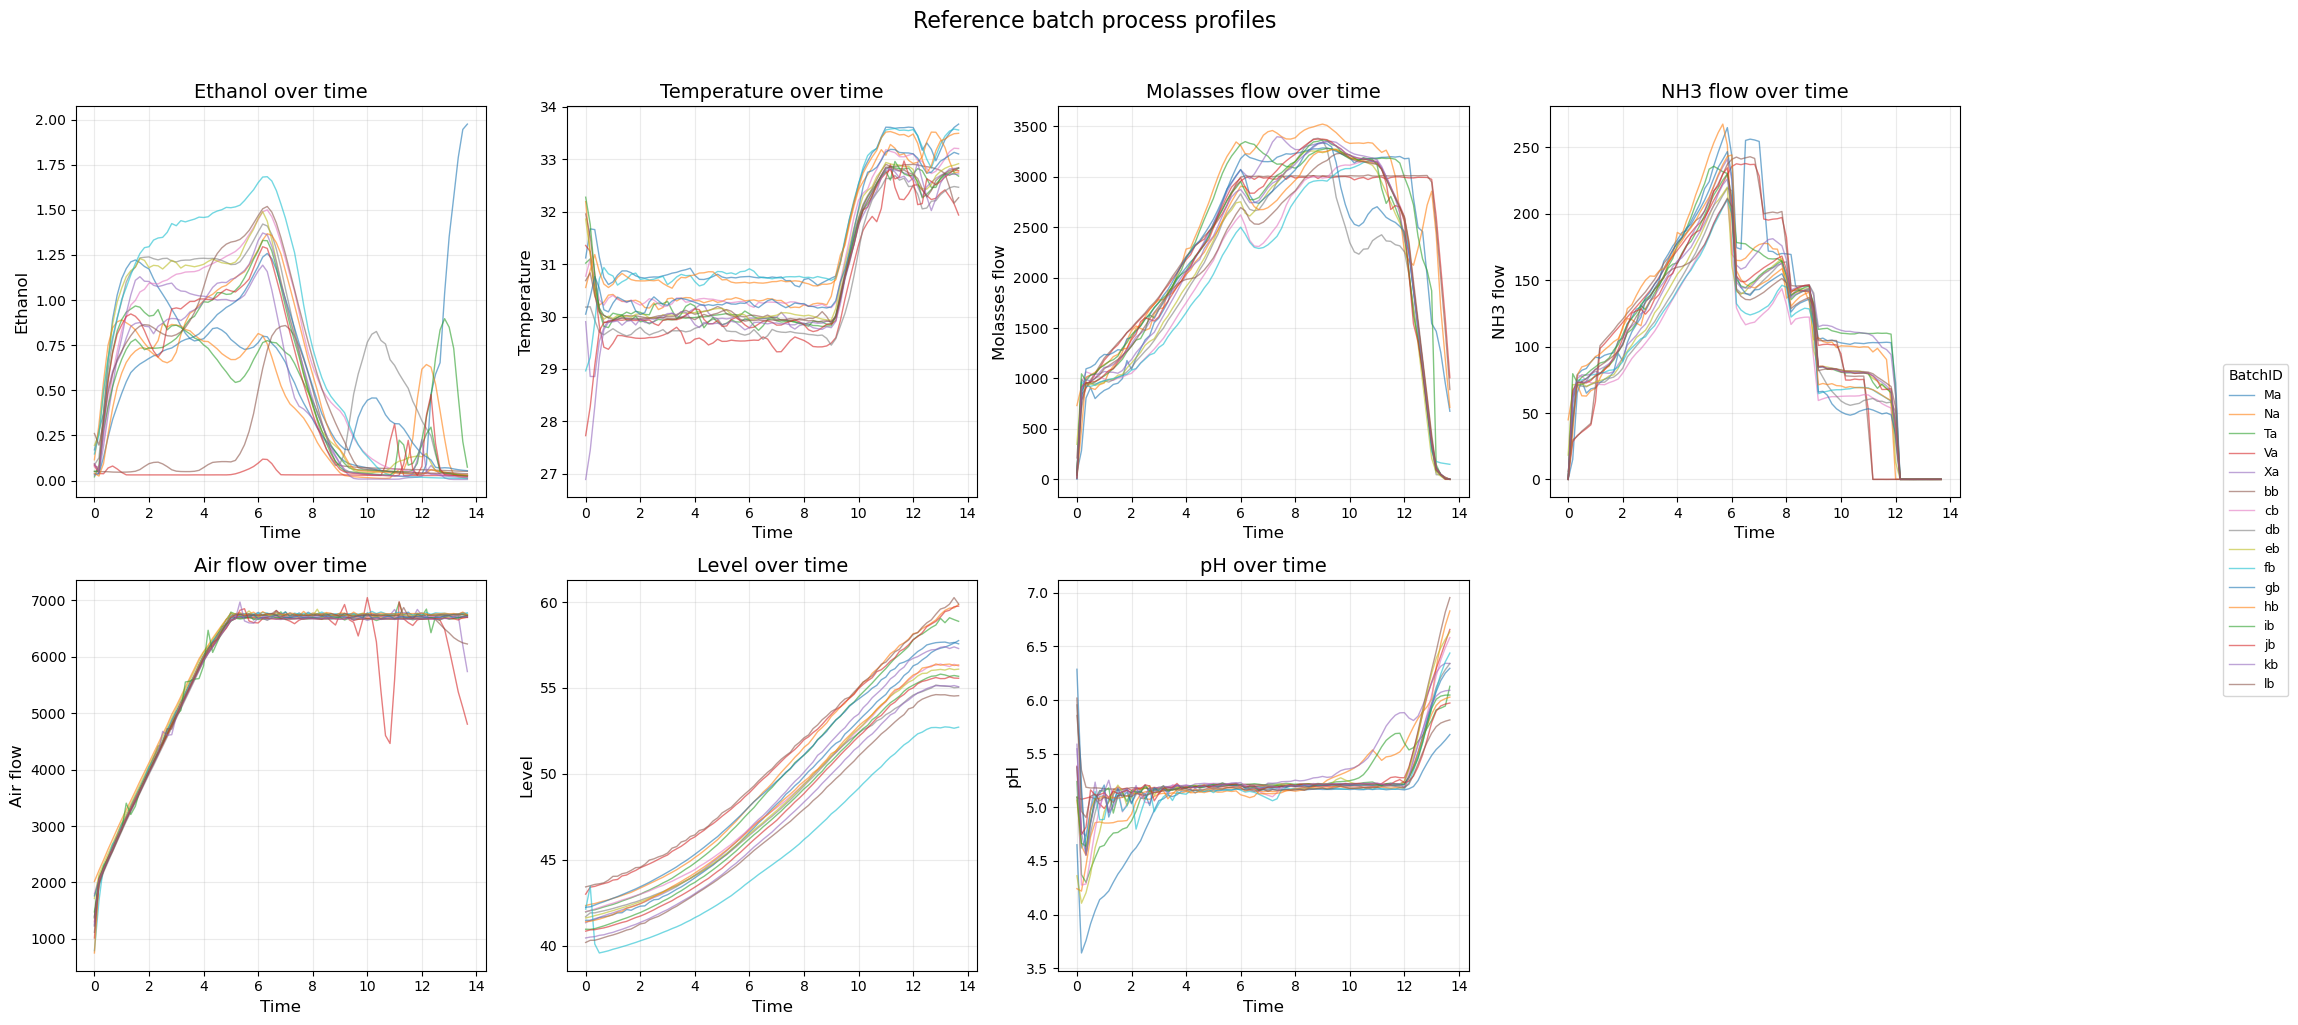

In [6]:
PROCESS_VARIABLES = [col for col in FEATURE_COLUMNS if col != TIME_COLUMN]

plot_process_profiles(
    reference_df,
    PROCESS_VARIABLES,
    title_prefix="Reference batch process profiles",
    filename="reference_process_profiles.png",
)


### EDA interpretation

The reference batch profiles show that several variables follow repeatable batch trajectories, but the amount of batch-to-batch variation differs by variable.

**Ethanol**, **Molasses flow**, **NH3 flow**, **Temperature**, and **pH** show visible differences between batches, especially during transition periods and near the end of the batch. **Air flow** follows a highly repeatable ramp-and-plateau pattern for most batches, although a few deviations are visible. **Level** follows a consistent increasing trend, but the final level differs across batches.

These patterns support the use of PCA because PCA can summarize the combined variation across all process variables into a smaller number of principal components.


## 7. Pre-processing and PCA model fitting

The measured process variables are standardized before PCA because they have different units and numerical scales. PCA is then fit with 5 components, preserving the original assignment's modeling approach.


In [7]:
scaler, pca, scaled_reference_df, scores_pd, loadings_pd, explained_variance_df = fit_scaled_pca(
    reference_df,
    FEATURE_COLUMNS,
    n_components=N_COMPONENTS,
)

print("Scaled reference data:")
display(scaled_reference_df.head())

print("PCA scores:")
display(scores_pd.head())

print("PCA loadings:")
display(loadings_pd)

print("Explained variance:")
display(explained_variance_df)


Scaled reference data:


,Time,Ethanol,Temperature,Molasses flow,NH3 flow,Air flow,Level,pH
0,-1.711307,-1.040118,0.845978,-2.120796,-1.598346,-3.108260,-0.966367,1.901904
1,-1.669568,-1.042825,0.502539,-1.460720,-1.235050,-2.619744,-0.954013,0.327319
2,-1.627829,-1.041923,-0.066219,-1.381616,-1.193143,-2.493099,-0.939485,-0.163079
3,-1.586089,-1.043140,-0.596433,-1.302324,-1.133709,-2.367622,-0.932474,-0.183918
4,-1.544350,-1.046728,-0.815327,-1.230888,-1.089118,-2.235362,-0.921788,-0.180769


PCA scores:


,PC1,PC2,PC3,PC4,PC5,BatchID,Time
0,-0.808176,-4.508288,0.200368,-1.295502,0.754945,bb,0.000000
1,-1.303347,-3.391210,-0.824346,-0.666865,0.552935,bb,0.166667
2,-1.630004,-3.073121,-1.085677,-0.706676,0.168488,bb,0.333333
3,-1.790453,-2.816650,-1.059588,-0.979711,-0.160562,bb,0.500000
4,-1.811100,-2.636318,-1.033483,-1.094550,-0.294213,bb,0.666667


PCA loadings:


,PC1,PC2,PC3,PC4,PC5
Time,0.471425,0.115005,0.073487,0.109928,-0.166210
Ethanol,-0.315056,0.164245,0.630171,0.587107,-0.255200
Temperature,0.399243,-0.203158,-0.051128,0.540846,0.647797
Molasses flow,0.127401,0.608623,-0.366748,0.045936,-0.239382
NH3 flow,-0.254209,0.542698,0.115348,-0.249949,0.618487
Air flow,0.318021,0.481637,0.256120,0.079962,0.044048
Level,0.472402,0.064508,-0.060503,0.001973,-0.210803
pH,0.337563,-0.132078,0.614657,-0.528890,0.037395


Explained variance:


,Principal Component,Explained Variance Ratio,Explained Variance (%),Cumulative Variance (%)
0,PC1,0.528601,52.860131,52.860131
1,PC2,0.256072,25.607245,78.467377
2,PC3,0.103760,10.375975,88.843351
3,PC4,0.064286,6.428613,95.271965
4,PC5,0.023534,2.353388,97.625353


## 8. PCA explained variance

The cumulative explained variance shows how much standardized process variation is captured as more principal components are added.

In this model, **PC1 and PC2 together explain about 78.5% of the total variance**, which is useful for two-dimensional visualization. However, they do not capture the full structure of the data. The cumulative variance exceeds the 95% threshold only after including **4 principal components**.

Therefore, PC1-PC2 plots are useful for visual monitoring and interpretation, while a more complete monitoring system should also consider additional PCs or formal statistics such as Hotelling's T² and SPE/Q residuals.


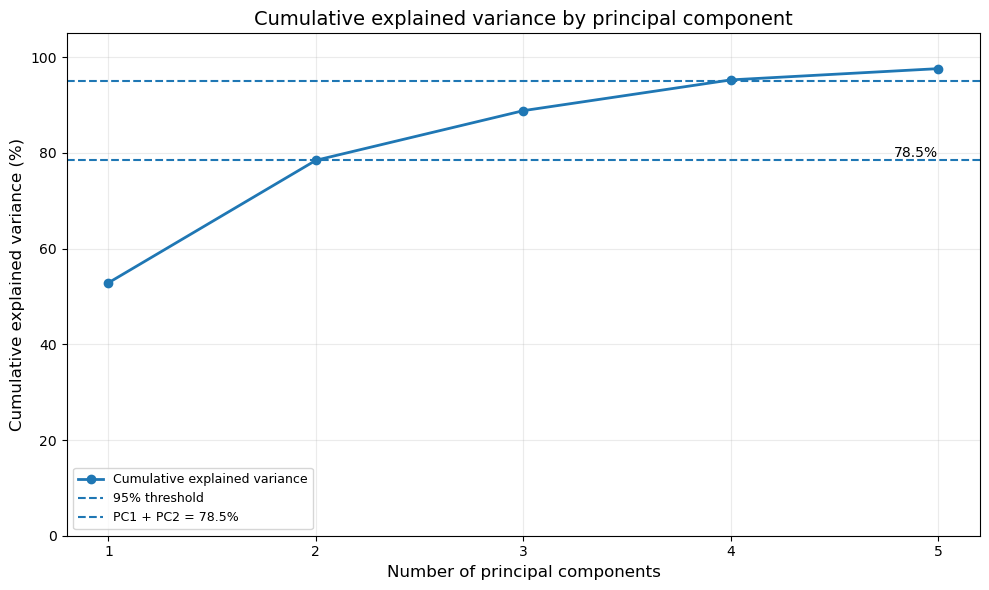

In [8]:
plot_explained_variance(
    explained_variance_df,
    filename="pca_cumulative_explained_variance.png",
)


## 9. PCA score trajectories for reference batches

The score trajectory plot shows how each reference batch moves through the PC1-PC2 space over time. Similar trajectories indicate similar multivariate process behavior.


PC1                                                    \
BatchID         Ma        Na        Ta        Va        Xa        bb   
Time                                                                   
0.000000 -2.575226 -2.494768 -1.834810 -1.935067 -1.953438 -0.808176   
0.166667 -3.406333 -2.944182 -2.731785 -1.704701 -3.044833 -1.303347   
0.333333 -3.390333 -3.070940 -3.117042 -1.841620 -3.172201 -1.630004   
0.500000 -3.534499 -2.888284 -3.194946 -2.016330 -2.751431 -1.790453   
0.666667 -3.596972 -2.732277 -3.165646 -2.107667 -2.436144 -1.811100   

                                                  ...       PC5            \
BatchID         cb        db        eb        fb  ...        cb        db   
Time                                              ...                       
0.000000 -1.732160 -1.483465 -2.607604 -2.574646  ...  0.132314 -0.132039   
0.166667 -2.818163 -2.245863 -3.134312 -3.146375  ...  0.526101 -0.060107   
0.333333 -3.018590 -3.095891 -3.340362 -3.181104  ...  0.346720 -0.127723   
0.500000 -2.938017 -3.043336 -3.349177 -2.775636  ...  0.083581 -0.355656   
0.666667 -2.735993 -2.909978 -3.199772 -2.511582  ... -0.060130 -0.456512   

                                                                      \
BatchID         eb        fb        gb        hb        ib        jb   
Time                                                                   
0.000000  0.617059 -0.897800 -0.128482 -0.009076  0.914290 -1.438659   
0.166667  0.570277 -0.552050  0.165896  0.371143  1.111206 -0.774914   
0.333333  0.087732 -0.075650  0.462843  0.755104  0.431340 -0.456887   
0.500000 -0.197882  0.306487  0.344080  0.594513  0.052315 -0.199308   
0.666667 -0.370031  0.384769  0.106633  0.404393 -0.123296 -0.218693   

                              
BatchID         kb        lb  
Time                          
0.000000 -1.833015  0.111854  
0.166667 -1.236314  0.332924  
0.333333 -0.850361  0.270976  
0.500000 -0.471139  0.038183  
0.666667 -0.224946 -0.038438  

[5 rows x 80 columns]

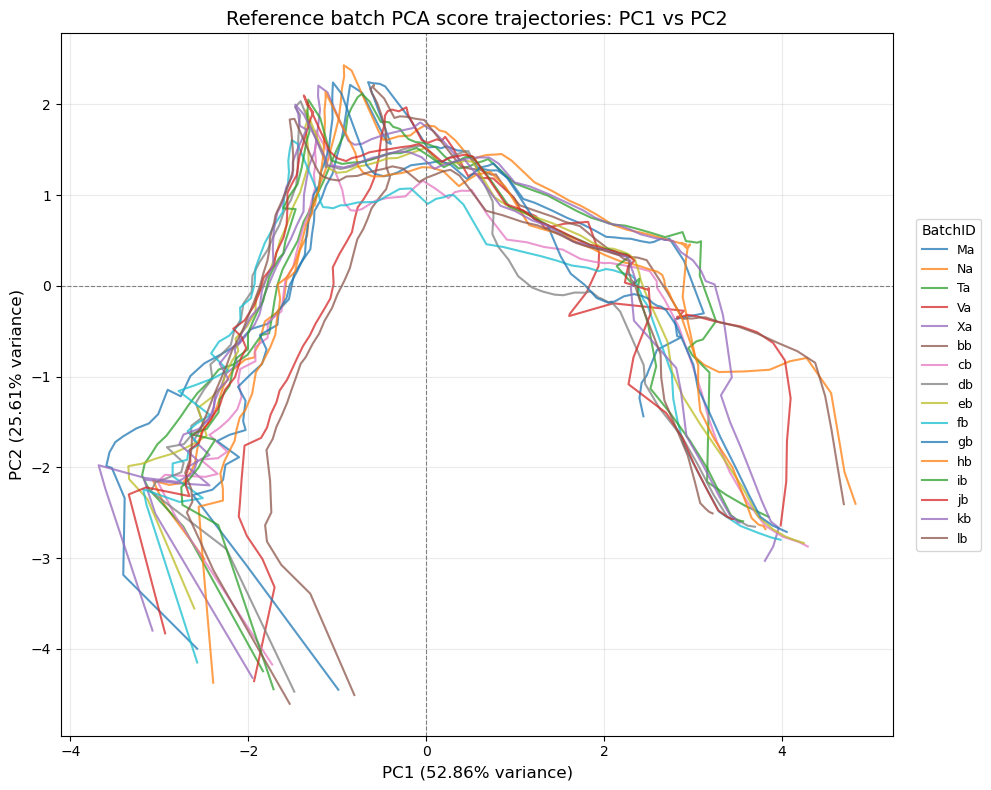

In [9]:
pc_columns = [f"PC{i + 1}" for i in range(N_COMPONENTS)]
reference_pivot = create_score_pivot(scores_pd, pc_columns)

display(reference_pivot.head())

plot_score_trajectories(
    reference_pivot,
    pca,
    title="Reference batch PCA score trajectories: PC1 vs PC2",
    filename="reference_score_trajectories.png",
)


## 10. PCA biplot: scores and loadings

This biplot overlays the reference batch trajectories with feature loading arrows. The arrows indicate which variables are most strongly associated with movement in the PC1-PC2 space.


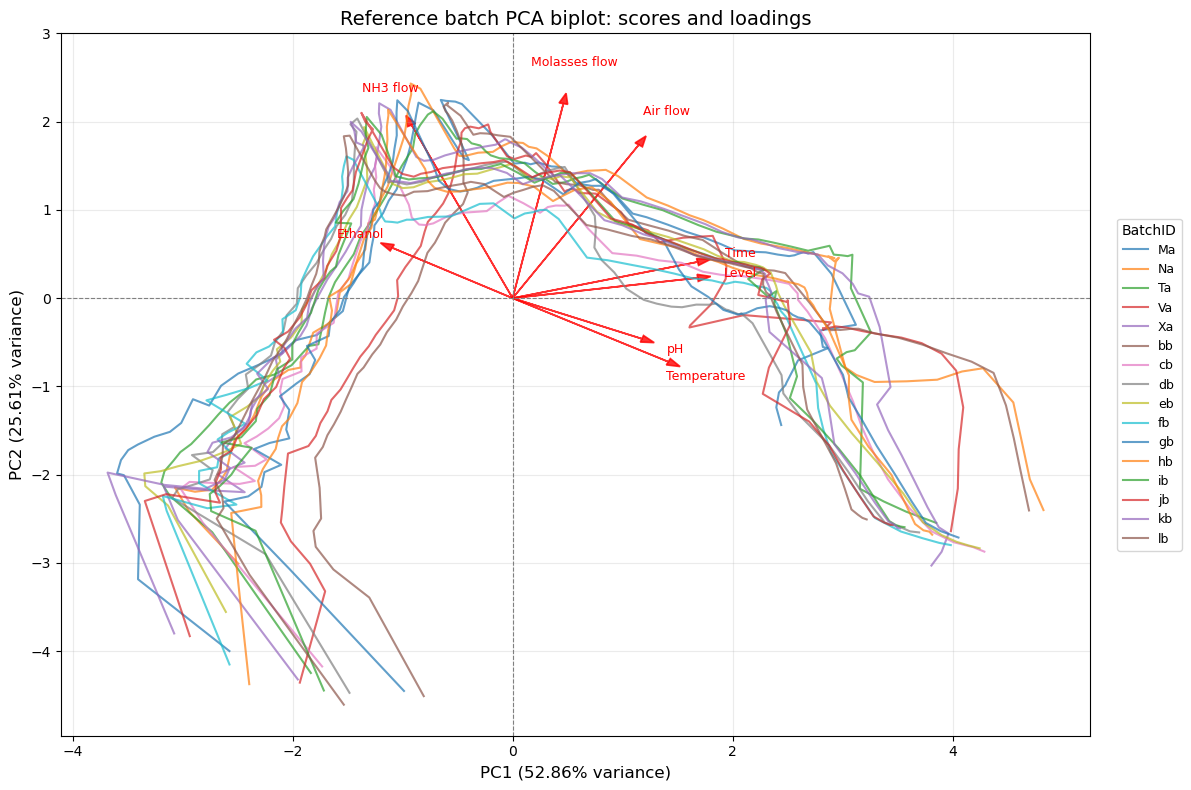

In [10]:
plot_biplot(
    reference_pivot,
    loadings_pd,
    pca,
    title="Reference batch PCA biplot: scores and loadings",
    filename="reference_pca_biplot.png",
    arrow_scale=0.40,
    y_top=3,
)


### Biplot interpretation

- Lines show the reference batch trajectories in PC1-PC2 score space.
- Red arrows show how the original process variables contribute to the first two principal components.
- Longer arrows indicate stronger contribution within the PC1-PC2 plane, not necessarily across the full PCA model.
- Arrows pointing in similar directions indicate variables that tend to increase together in this PCA space.
- Arrows pointing in opposite directions indicate variables that vary in opposite directions.
- Batch trajectories moving toward a loading arrow are associated with higher values of that process variable.
- A batch trajectory that moves outside the reference trajectory region may indicate abnormal process behavior or a process condition not well represented by the reference batches.


# Monitoring today's running batches

The current batches are projected into the same PCA space using the **already fitted reference scaler and PCA model**. The model is not refit on today's data because that would change the PCA coordinate system and make comparison invalid.


## 11. Load and inspect today's batches


In [11]:
today_df = load_batch_data(TODAY_DATA_PATH)
validate_required_columns(today_df, [BATCH_COLUMN] + FEATURE_COLUMNS, "today's batch data")

print(f"Rows: {today_df.shape[0]}")
print(f"Columns: {today_df.shape[1]}")
print(f"Number of current batches: {today_df[BATCH_COLUMN].nunique()}")

display(today_df.head())


Rows: 166
Columns: 10
Number of current batches: 2


,Primary ID,BatchID,Time,Ethanol,Temperature,Molasses flow,NH3 flow,Air flow,Level,pH
0,2574,Ya,0.000000,0.30350,29.0885,-0.70954,0.00356,1250.69,41.9216,4.86282
1,2575,Ya,0.166667,0.41224,29.5509,-1.49002,0.00712,2040.08,41.9911,4.00324
2,2576,Ya,0.333333,1.16614,29.9639,-1.63193,0.00712,2235.08,42.3624,4.05839
3,2577,Ya,0.500000,2.22696,29.9746,1280.07000,82.08680,2419.08,42.8531,4.35465
4,2578,Ya,0.666667,3.13590,29.9466,844.09600,74.65800,2603.53,43.2146,4.76967


## 12. Transform today's batches using the reference PCA model

The critical step is to use `scaler.transform()` and `pca.transform()`, not `fit_transform()`. This keeps today's data in the same standardized PCA space as the reference model.


In [12]:
scores_pd_today = transform_batches_with_reference_model(
    today_df,
    FEATURE_COLUMNS,
    scaler,
    pca,
)

current_pivot = create_score_pivot(scores_pd_today, pc_columns)

display(scores_pd_today.head())
display(current_pivot.head())


,PC1,PC2,PC3,PC4,PC5,BatchID,Time
0,-3.096781,-3.798958,-1.166746,-0.602916,-0.937231,Ya,0.000000
1,-3.715861,-3.216763,-2.529801,1.183846,-0.839431,Ya,0.166667
2,-3.928722,-2.972255,-1.411527,2.217525,-1.037556,Ya,0.333333
3,-4.362027,-1.145315,0.230988,2.807162,-1.130690,Ya,0.500000
4,-4.476710,-1.268811,2.409623,3.259502,-1.559791,Ya,0.666667


PC1                 PC2                 PC3            \
BatchID         Ya        Za        Ya        Za        Ya        Za   
Time                                                                   
0.000000 -3.096781 -0.660359 -3.798958 -4.613764 -1.166746  1.802298   
0.166667 -3.715861 -2.032155 -3.216763 -2.849667 -2.529801 -0.423385   
0.333333 -3.928722 -2.734359 -2.972255 -2.229773 -1.411527 -1.511814   
0.500000 -4.362027 -2.523621 -1.145315 -2.247428  0.230988 -0.916732   
0.666667 -4.476710 -2.356751 -1.268811 -2.592231  2.409623 -0.100159   

               PC4                 PC5            
BatchID         Ya        Za        Ya        Za  
Time                                              
0.000000 -0.602916 -2.854773 -0.937231  0.030840  
0.166667  1.183846 -1.492080 -0.839431 -0.011713  
0.333333  2.217525  0.031252 -1.037556  0.072634  
0.500000  2.807162  0.437946 -1.130690  0.224712  
0.666667  3.259502  0.325745 -1.559791  0.049787

## 13. Current batch score trajectories

This plot shows only the current batches in the reference PCA space.


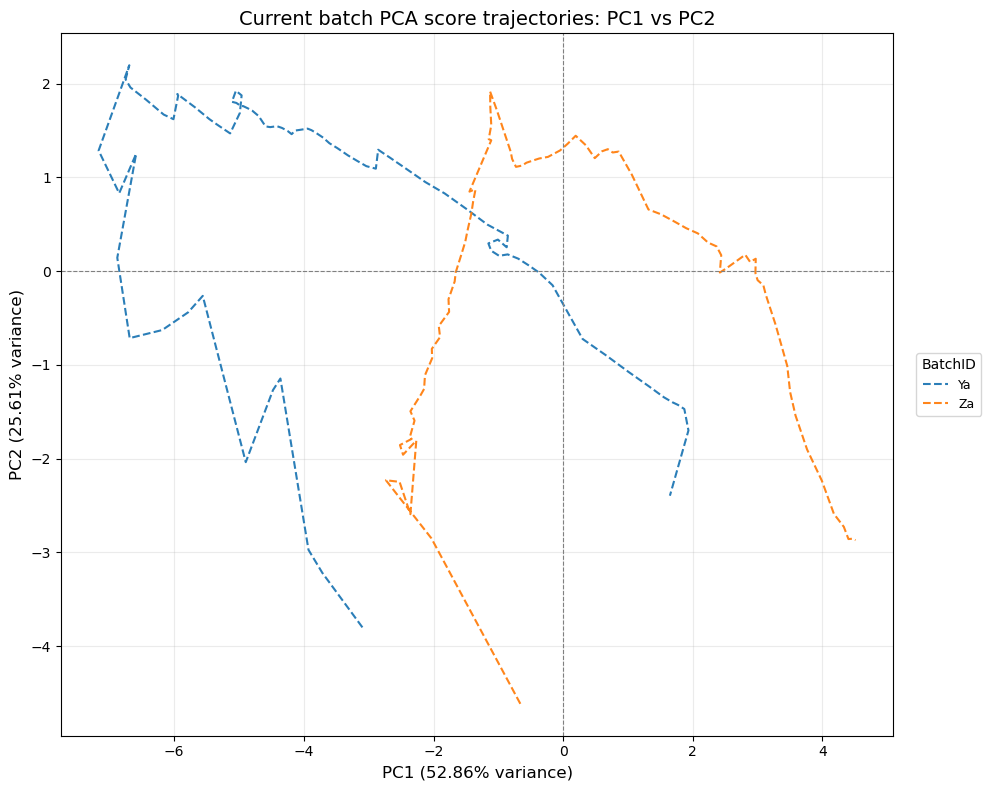

In [13]:
plot_score_trajectories(
    current_pivot,
    pca,
    title="Current batch PCA score trajectories: PC1 vs PC2",
    filename="current_score_trajectories.png",
    linestyle="--",
    alpha=0.95,
)


## 14. Reference vs current batch monitoring plot

The reference batches are shown as muted solid gray lines. The current batches are shown as emphasized dashed lines. This makes it easier to identify current batches that deviate from the reference operating behavior.


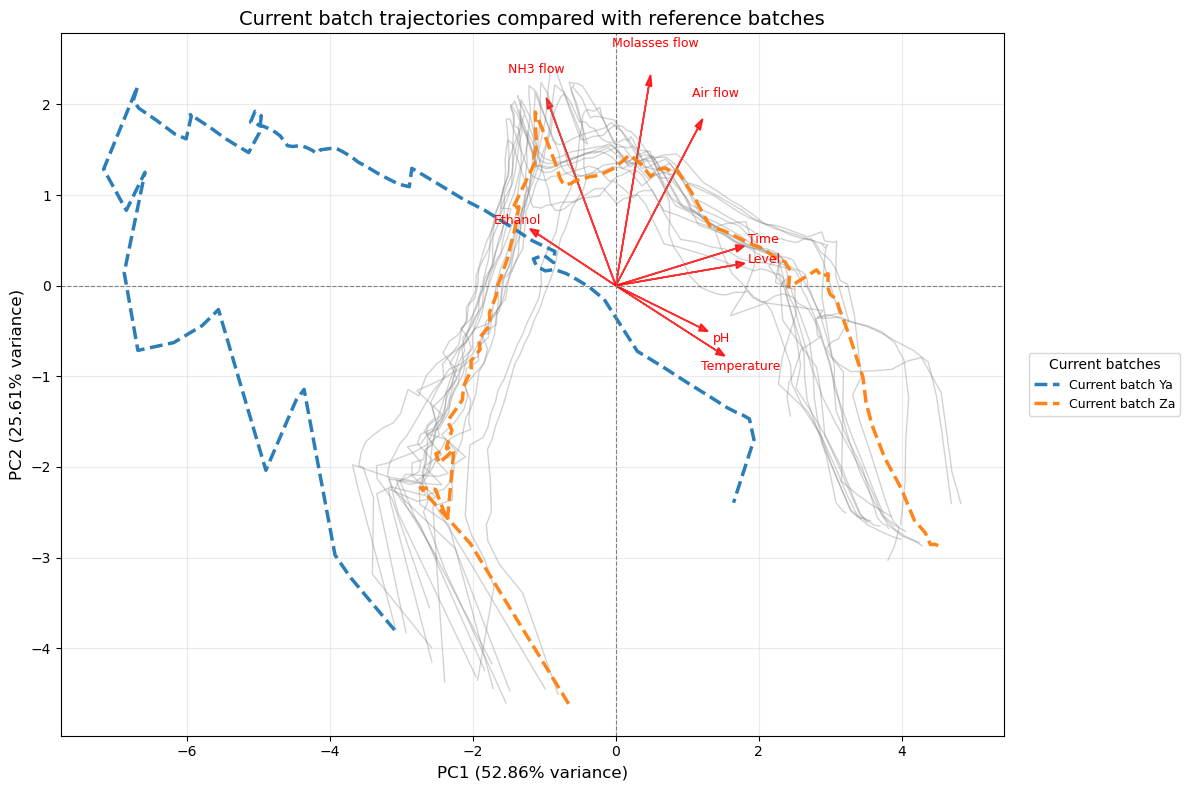

In [14]:
plot_reference_vs_current_batches(
    reference_pivot,
    current_pivot,
    loadings_pd,
    pca,
    filename="reference_vs_current_batches.png",
)


## 15. Monitoring interpretation

Use the overlay plot to compare each current batch against the historical reference trajectories.

- A current batch that follows the reference trajectory closely is behaving similarly to historical normal batches.
- A current batch that moves outside the reference trajectory region may indicate a potential process deviation.
- The loading arrows help identify which process variables may be contributing to the deviation.

Based on the overlay plot, batch **Za** appears more consistent with the reference batch behavior because much of its trajectory overlaps the historical operating region. However, it still shows some deviation near parts of the trajectory and should not be treated as perfectly normal without further review.

Batch **Ya** shows a stronger deviation from the reference behavior. Its trajectory moves farther to the left of the reference region and remains separated from the historical trajectories for a noticeable portion of the run. This suggests that batch Ya may require closer process investigation.


## 16. Final conclusion

This notebook built a PCA-based batch monitoring model using historical reference batches for baker's yeast production. The process variables were standardized and summarized with a 5-component PCA model. The first two principal components were used for visualization, while the cumulative explained variance shows that the first four components are needed to capture more than 95% of the total standardized process variation.

Key insights:

- The reference batches form a broadly repeatable trajectory pattern in PC1-PC2 space, although some batch-to-batch variation is present.
- PC1 and PC2 capture about 78.5% of the total variance, making them useful for visualization but not a complete representation of all process variation.
- PCA loadings help identify which process variables are associated with movement in the PC1-PC2 score space.
- Today's batches can be monitored by transforming them with the reference scaler and PCA model, rather than refitting PCA on the current data.
- Batch **Za** appears broadly more consistent with the reference trajectories, although some deviations are still visible.
- Batch **Ya** shows a stronger deviation from the reference operating region, especially where its trajectory moves far to the left of the historical batch trajectories.

Limitations:

- PCA monitoring here is visual and qualitative; formal control limits such as Hotelling's T² and SPE/Q residual statistics were not added.
- PC1-PC2 plots do not capture all variation in the process data.
- Time alignment is assumed to be adequate across batches.
- The model depends on the reference batches being representative of normal operation.

Possible next improvements:

- Add Hotelling's T² and SPE/Q residual control limits for quantitative fault detection.
- Investigate which original process variables are driving the deviation in batch Ya.
- Add batch trajectory alignment if future batches have unequal durations.
- Create automated alerts when current batch scores exceed reference control limits.
